**Uwagi znajdują się w komentarzach w kodzie i pod kodem jest małe podsumowanie.**

In [34]:
# ładowanie klasyfikatorów, modułów i funkcji potrzebnych w tym programie
from pathlib import Path
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import Lasso, Ridge, LinearRegression, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier
import joblib
"""
ładowanie danych treningowych w problemie titanic
nie jest to zbyt intuicyjnie zrobione bo najpierw tworzy się katalog data/titanicData
po czym, po drugim załadowaniu funkcji load_titanic_data należy załadować dane treningowe które znajdują się w zmiennej filename
dane treningowe ładujemy samodzielnie w folderze pliki po lewej stronie ekranu
"""
def load_titanic_data():
      filename = "train(1).csv"
      Path("data/titanicData").mkdir(parents=True, exist_ok=True)
      return pd.read_csv(Path("data/titanicData") / filename)

train_data = load_titanic_data()


In [35]:
# kilka metod które pozwalają na poznanie danych
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [37]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [38]:
train_data["Survived"].value_counts()

,count
Survived,
0,549
1,342


In [39]:
train_data["Pclass"].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [40]:
train_data["Sex"].value_counts()



,count
Sex,
male,577
female,314


In [41]:
train_data["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [42]:
# tutaj zajmujemy się uzupełnieniem danych których brakuje w danych titanic, uzupełniamy dane liczbowe(Age) jak i kategoryczne(Embarked)
imputer = SimpleImputer(strategy='mean')
train_data[['Age']] = imputer.fit_transform(train_data[['Age']])
imputer_2 = SimpleImputer(strategy='most_frequent')
#train_data['Cabin'] = imputer_2.fit_transform(train_data[['Cabin']).ravel()
train_data['Embarked'] = imputer_2.fit_transform(train_data[['Embarked']]).ravel()
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [43]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


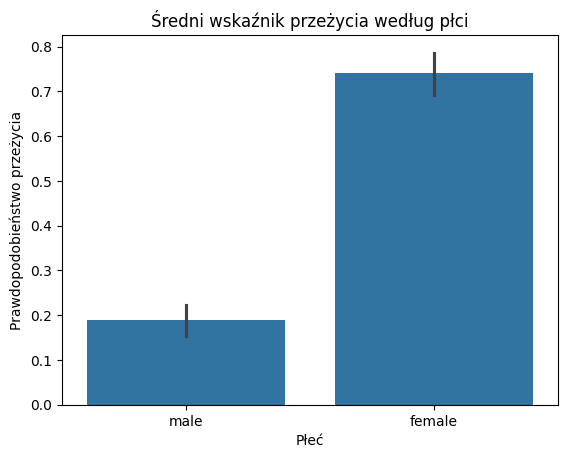

In [44]:
#tutaj zaczynam wyświetlać kilka wykresów które pozwalają poznać relacje między zmiennymi, co mogło pomóc w wyborze odpowiednich cech
#do modeli
sns.barplot(x="Sex", y="Survived", data=train_data)
plt.title("Średni wskaźnik przeżycia według płci")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.xlabel("Płeć")
plt.show()

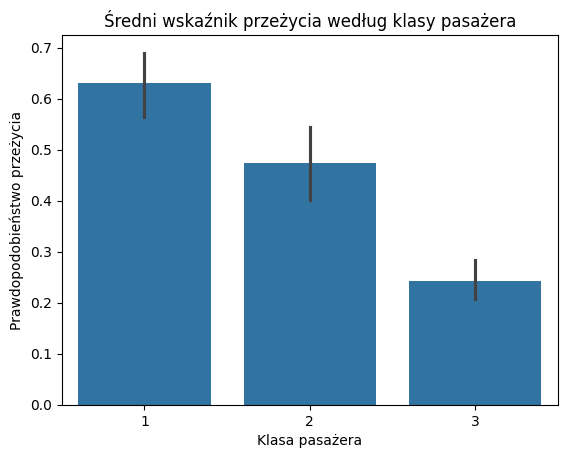

In [45]:
sns.barplot(x="Pclass", y="Survived", data=train_data)
plt.title("Średni wskaźnik przeżycia według klasy pasażera")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.xlabel("Klasa pasażera")
plt.show()

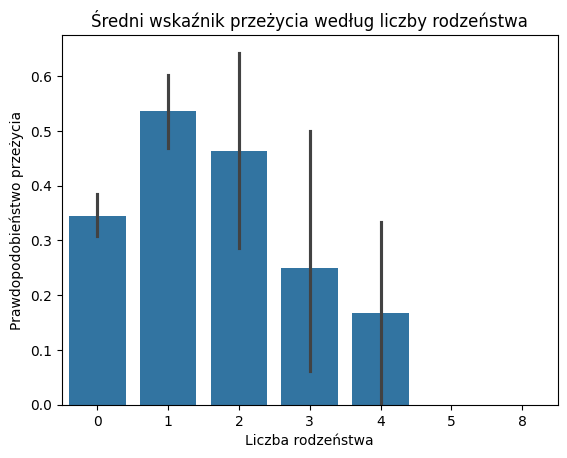

In [46]:
sns.barplot(x="SibSp", y="Survived", data=train_data)
plt.title("Średni wskaźnik przeżycia według liczby rodzeństwa")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.xlabel("Liczba rodzeństwa")
plt.show()

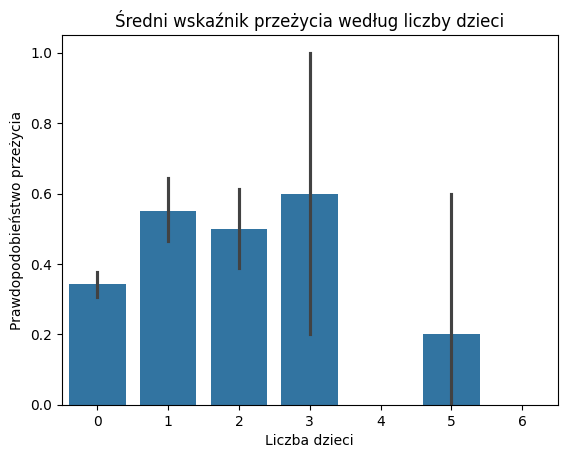

In [47]:
sns.barplot(x="Parch", y="Survived", data=train_data)
plt.title("Średni wskaźnik przeżycia według liczby dzieci")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.xlabel("Liczba dzieci")
plt.show()

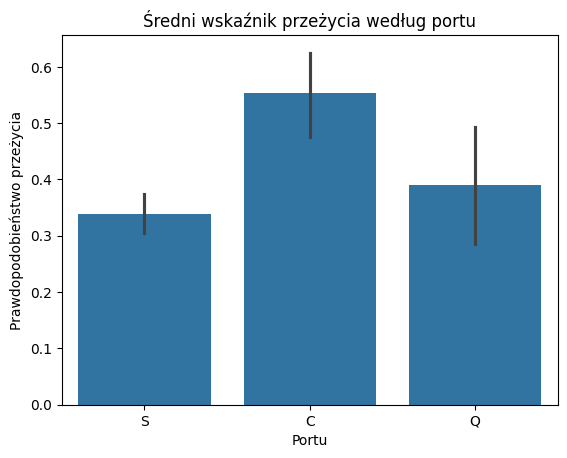

In [48]:
sns.barplot(x="Embarked", y="Survived", data=train_data)
plt.title("Średni wskaźnik przeżycia według portu")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.xlabel("Portu")
plt.show()

In [49]:
# wyodrębniam true labels potrzebną do wytrenowania klasyfikatora
y = train_data["Survived"]
# usuwamy niepotrzebne kolumny-cechy w train_data - zmiennej przechowującej dane treningowe
train_data = train_data.drop(columns=['Cabin','Name', 'Survived', 'PassengerId'])
# usuwam kolejną kolumnę
train_data = train_data.drop(columns=['Ticket'])

# w tym miejscu zaczynam standaryzację i konwersję zmiennych kategorycznych na sekwencję zero-jedynkową
# następnym razem zrobię to poprzez Pipeline bo będzie prościej ale chciałem to zrobić "po swojemu" i wyszło trochę dziwnie - niestety
categorical_cols = ['Sex', 'Embarked']
numerical_cols = ['Pclass', 'SibSp', 'Parch', 'Age', 'Fare']

# separuje dane kategoryczne od numerycznych
train_data_categorical = train_data[categorical_cols]
train_data_numerical = train_data[numerical_cols]
# w zmiennej encoder otrzymujemy tablicę gęstą dzięki parametrowi sparse_output=False
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Use sparse_output=False for dense array directly

# tutaj robimy naszą transformację, zamieniamy dane kategoryczne na sekwencję zero-jedynkowe
encoded_array = encoder.fit_transform(train_data_categorical)

# tworzymy DataFrame z odpowiednimi nazwami kolumn
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols), index=train_data.index)

# robimy standaryzację, czyli ustalamy średnią danych numerycznych na zero a odchylenie standardowe na 1
scaler = StandardScaler()
scaled_numerical_array = scaler.fit_transform(train_data_numerical)

# tak samo jak poprzednio tworzymy DataFrame który później będziemy scalać
scaled_numerical_df = pd.DataFrame(scaled_numerical_array, columns=numerical_cols, index=train_data.index)


# scalamy dwa DataFRame
X = pd.concat([scaled_numerical_df, encoded_df], axis=1)

In [50]:
# dzielimy dane na treningowe i testowe
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# nasz pierwszy klasyfikator losowy las decyzyjny
forest_clf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42)
# trenujemy nasz model
forest_clf.fit(X_train, y_train)
# zrzucamy wytrenowany model do pliku i później możemy go załadować aby zrobić predyckję
joblib.dump(forest_clf, 'forest_model.pkl')
# wyświetlamy rezulaty działania naszego modelu
print("score dla danych treningowych ", forest_clf.score(X_train, y_train))

print("score dla danych testowych ", forest_clf.score(X_test, y_test))

score dla danych treningowych  0.9424157303370787
score dla danych testowych  0.8212290502793296


In [51]:
#forest_scores = cross_val_score(forest_clf, X_train, y_train, cv=10)
#forest_scores.mean()

In [52]:
# kolejny klasyfikator drzewo decyzyjne
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=2)

tree_clf.fit(X_train, y_train)
print("score dla danych treningowych ", tree_clf.score(X_train, y_train))

print("score dla danych testowych ", tree_clf.score(X_test, y_test))

score dla danych treningowych  0.9157303370786517
score dla danych testowych  0.8044692737430168


In [53]:
# następny klasyfikator oparty o maszynę wektorów nośnych
svm_clf = SVC(kernel="linear", C=100)

In [54]:
svm_clf.fit(X_train, y_train)
print("score dla danych treningowych ", svm_clf.score(X_train, y_train))

print("score dla danych testowych ", svm_clf.score(X_test, y_test))


score dla danych treningowych  0.7879213483146067
score dla danych testowych  0.7821229050279329


In [55]:
# chyba najbardziej popularny klasyfikator przynajmniej w regresji
clf = LinearRegression()
clf.fit(X_train, y_train)

print("score dla danych treningowych ", clf.score(X_train, y_train))
print("score dla danych testowych    ", clf.score(X_test, y_test))

score dla danych treningowych  0.3845118957517023
score dla danych testowych     0.4432783450214831


In [56]:
# zmieniamy liniowy klasyfikator na nieliniowy
clf_poly = Pipeline([("poly", PolynomialFeatures(degree=8)), ("clf_poly", LinearRegression())])
clf_poly.fit(X_train, y_train)

print("score dla danych treningowych ", clf_poly.score(X_train, y_train))
print("score dla danych testowych   ", clf_poly.score(X_test, y_test))

score dla danych treningowych  0.8304928344510356
score dla danych testowych    -6716800623.939389


In [57]:
# klasyfikator Lasso
#clf_lasso = Lasso(alpha=0.1)
clf_lasso = Pipeline([("poly", PolynomialFeatures(degree=8)), ("clf_lasso", Lasso(alpha=0.1))])
clf_lasso.fit(X_train, y_train)

print("score dla danych treningowych ", clf_lasso.score(X_train, y_train))
print("score dla danych testowych    ", clf_lasso.score(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.326e+01, tolerance: 1.671e-02
  model = cd_fast.enet_coordinate_descent(


score dla danych treningowych  0.2869382783471305
score dla danych testowych     0.20664218324508543


In [58]:
# klasyfikator Ridge
clf_ridge = Pipeline([("poly", PolynomialFeatures(degree=6)), ("clf_ridge", Ridge(alpha=1.0))])
clf_ridge.fit(X_train, y_train)

print("score dla danych treningowych ", clf_ridge.score(X_train, y_train))
print("score dla danych testowych    ", clf_ridge.score(X_test, y_test))

score dla danych treningowych  0.7079134492170935
score dla danych testowych     -1846.4143879553792


In [59]:
# klasyfikator ElasticNet
clf_elastic = Pipeline([("poly", PolynomialFeatures(degree=4)), ("clf_elastic", ElasticNet())])
clf_elastic.fit(X_train, y_train)

print("score dla danych treningowych ", clf_elastic.score(X_train, y_train))
print("score dla danych testowych    ", clf_elastic.score(X_test, y_test))

score dla danych treningowych  0.02126665309848419
score dla danych testowych     -0.002404694309618538


In [60]:
# ostatni użyty klasyfikator AdaBoostClassifier
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=4), n_estimators=300,
    learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

print(" score danych treningowych ", ada_clf.score(X_train, y_train))
print(" score danych testowych    ", ada_clf.score(X_test, y_test))

 score danych treningowych  0.922752808988764
 score danych testowych     0.8268156424581006


Co mogę dodać poza komentarzami w kodzie? Myślę, że można lepiej zrobić ładowanie danych treningowych jak i samą standaryzację. W kolejnych projektach będę używał do tego Piipeline, tutaj zacząłem robić po swojemu, utknąłem przy problemie i chciałem go za wszelką cenę rozwiązać a jak rozwiązałem to nie miałem ochoty na robienie standaryzacji poprzez Pipeline.
Może krótki komentarz do danych z których zrezygnowałem, czyli które kolumny i dlaczego usunąłem:
 - Cabin: tych danych jest najmniej i dlatego usunąłem tą kolumnę,
 - Name: wydaję mi się, że w tym prejekcie imię i nazwisko nie są istotne, trudno robić predykcję wpisując jakieś nazwisko, to wydaje się bez sensu przynajmniej w tym projekcie
 - Survived: nasza true labels nie jest potrzebna w danych wejściowych
 - PassengerId: podobnie jak w Name, do predykcji chyba nie jest potrzebny, aczkolwiek tutaj się wahałem bo podobno w danych trzeba mieć kolmnę która jest indeksem
 - Ticket: cecha zbyt zmienna aby była potrzebna

Krótkie podsumowanie klasyfikatorów:
 - najlepsze: RandomForestClassifier, DecisionTreeClassifier, AdaBoostClassifier
 - najgorsze: LinearRegression, Lasso, Ridge, ElasticNet

 SVM spisał się przeciętnie.

 Poza tym zrobiłem zapisywanie(zrzut) wytrenowanego modelu do pliku aby go później można używać na przykład w aplikacji internetowej.

 I to chyba wszystko. Na wszelkie uwagi jestem otwarty.  